# TP2 — Segmentation RFM & Clustering Lumina & Co

> **Objectif** : Répondre à la question du CMO : *"Qui sont nos clients ?"* via une segmentation RFM enrichie et un clustering K-means, avec des recommandations marketing actionnables.

---

## Sommaire
1. [Chargement & Reconstruction du dataset nettoyé](#etape0)
2. [Construction des features RFM enrichies](#etape1)
3. [Scoring RFM & premiers segments](#etape2)
4. [Clustering K-means](#etape3)
5. [Comparaison RFM vs Clustering](#etape4)
6. [Visualisation & Profilage final](#etape5)
7. [Recommandations marketing par segment](#etape6)

---

---
## Étape 0 — Chargement du dataset nettoyé <a id='etape0'></a>

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# Style global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14

# ── Chargement des fichiers nettoyés ──────────────────
customers_clean = pd.read_csv('customers_clean.csv')
txn_clean       = pd.read_csv('transactions_clean.csv')
returns         = pd.read_csv('returns.csv')
campaigns       = pd.read_csv('campaigns.csv')

# Reconversion des dates
customers_clean['first_purchase'] = pd.to_datetime(customers_clean['first_purchase'])
customers_clean['last_purchase']  = pd.to_datetime(customers_clean['last_purchase'])
txn_clean['invoice_date']         = pd.to_datetime(txn_clean['invoice_date'])
returns['invoice_date']           = pd.to_datetime(returns['invoice_date'])
campaigns['start_date']           = pd.to_datetime(campaigns['start_date'])
campaigns['end_date']             = pd.to_datetime(campaigns['end_date'])

# Garantir le bon type pour is_b2b_suspect
customers_clean['is_b2b_suspect'] = customers_clean['is_b2b_suspect'].astype(bool)

print(f"customers_clean : {len(customers_clean):,} lignes | {customers_clean.shape[1]} colonnes")
print(f"txn_clean       : {len(txn_clean):,} lignes | {txn_clean.shape[1]} colonnes")
print(f"returns         : {len(returns):,} lignes")
print(f"campaigns       : {len(campaigns):,} campagnes")

customers_clean : 50,000 lignes | 10 colonnes
txn_clean       : 1,790,500 lignes | 11 colonnes
returns         : 23,314 lignes
campaigns       : 6 campagnes


---
## Étape 1 — Construction des features RFM enrichies <a id='etape1'></a>

### 1.1 Snapshot date & RFM de base

In [64]:
# ─── Snapshot date : max de invoice_date dans le dataset ────────────────────
SNAPSHOT_DATE = txn_clean['invoice_date'].max()
print(f"Snapshot date (date de référence) : {SNAPSHOT_DATE.date()}")
print("On n'utilise pas la date du jour — les données s'arrêtent à cette date.")

Snapshot date (date de référence) : 2011-12-09
On n'utilise pas la date du jour — les données s'arrêtent à cette date.


In [65]:
# ─── RFM de base à partir de txn_clean (clients identifiés uniquement) ─────
txn_id = txn_clean[~txn_clean['is_anonymous']].copy()

rfm_base = txn_id.groupby('customer_id').agg(
    last_purchase_date = ('invoice_date', 'max'),
    first_purchase_date= ('invoice_date', 'min'),
    frequency          = ('invoice_id', 'nunique'),
    monetary           = ('line_total', 'sum')
).reset_index()

rfm_base['recency'] = (SNAPSHOT_DATE - rfm_base['last_purchase_date']).dt.days
rfm_base['tenure']  = (rfm_base['last_purchase_date'] - rfm_base['first_purchase_date']).dt.days

print(f"Clients avec transactions identifiées : {len(rfm_base):,}")
display(rfm_base.head(5))

Clients avec transactions identifiées : 48,866


,customer_id,last_purchase_date,first_purchase_date,frequency,monetary,recency,tenure
0,12346.0,2011-01-18 10:01:00,2009-12-14 08:34:00,14,77556.46,325,400
1,12347.0,2011-12-07 15:52:00,2010-10-31 14:20:00,15,5633.32,1,402
2,12348.0,2011-09-25 13:13:00,2010-09-27 14:59:00,6,2019.40,74,362
3,12349.0,2011-11-21 09:51:00,2010-04-29 13:20:00,7,4428.69,18,570
4,12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,2,334.40,309,0


### 1.2 Features comportementales enrichies

In [66]:
# ─── Features comportementales additionnelles ───────────────────────────────

# A. Panier moyen par commande
basket_avg = (
    txn_id.groupby(['customer_id','invoice_id'])['line_total'].sum()
    .reset_index()
    .groupby('customer_id')['line_total'].mean()
    .rename('avg_basket')
)

# B. Nombre de catégories distinctes achetées
# On utilise les 3 premières lettres du product_code comme proxy de catégorie
txn_id['product_category'] = txn_id['product_code'].str[:3]
n_categories = (
    txn_id[txn_id['is_product']]
    .groupby('customer_id')['product_category'].nunique()
    .rename('n_categories')
)

# C. Proportion d'achats en période promotionnelle
#    On identifie les périodes de promotion depuis campaigns.csv
def is_promo_period(date):
    for _, row in campaigns.iterrows():
        if row['start_date'] <= date <= row['end_date']:
            return True
    return False

# Approche vectorisée : créer un set de dates promo
promo_dates = set()
for _, row in campaigns.iterrows():
    dates = pd.date_range(row['start_date'], row['end_date'], freq='D')
    promo_dates.update(dates.normalize())

txn_id['invoice_day'] = txn_id['invoice_date'].dt.normalize()
txn_id['is_promo']    = txn_id['invoice_day'].isin(promo_dates)

promo_ratio = (
    txn_id.groupby('customer_id')['is_promo'].mean()
    .rename('promo_ratio')
)

# D. Taux de retour (returns / achats)
returns_id = returns[~returns['is_anonymous']].copy()
n_returns_per_client = (
    returns_id.groupby('customer_id').size()
    .rename('n_returns')
)
n_invoices_per_client = (
    txn_id.groupby('customer_id')['invoice_id'].nunique()
    .rename('n_invoices')
)
return_rate = (n_returns_per_client / n_invoices_per_client).fillna(0).rename('return_rate')

# ─── Assemblage ─────────────────────────────────────────────────────────────
rfm = rfm_base.copy()
rfm = rfm.merge(basket_avg,   on='customer_id', how='left')
rfm = rfm.merge(n_categories, on='customer_id', how='left')
rfm = rfm.merge(promo_ratio,  on='customer_id', how='left')
rfm = rfm.merge(return_rate,  on='customer_id', how='left')

# Valeurs manquantes : clients sans retours → 0
rfm['n_categories'] = rfm['n_categories'].fillna(1)
rfm['promo_ratio']  = rfm['promo_ratio'].fillna(0)
rfm['return_rate']  = rfm['return_rate'].fillna(0)
rfm['avg_basket']   = rfm['avg_basket'].fillna(rfm['monetary'] / rfm['frequency'])

# Flag B2B
rfm = rfm.merge(customers_clean[['customer_id','is_b2b_suspect','country']], 
                on='customer_id', how='left')

print(f"Dataset RFM enrichi : {rfm.shape}")
display(rfm.describe().round(2))

Dataset RFM enrichi : (48866, 13)


,customer_id,last_purchase_date,first_purchase_date,frequency,monetary,recency,tenure,avg_basket,n_categories,promo_ratio,return_rate
count,48866.00,48866,48866,48866.00,48866.00,48866.00,48866.00,48866.00,48866.00,48866.00,48866.00
mean,37862.71,2010-12-15 09:56:21.624851,2010-05-24 01:35:11.833995,5.57,640.76,359.04,205.30,72.35,10.79,0.39,0.04
min,12346.00,2007-07-06 12:20:00,2007-07-06 12:20:00,1.00,0.19,0.00,0.00,0.19,1.00,0.00,0.00
25%,24923.25,2010-05-22 12:20:00,2009-11-20 12:20:00,1.00,29.35,87.00,0.00,17.60,2.00,0.00,0.00
50%,37917.50,2011-03-15 12:20:00,2010-04-29 19:21:30,2.00,86.20,269.00,83.00,33.67,6.00,0.26,0.00
75%,50767.50,2011-09-13 12:20:00,2010-12-21 12:20:00,6.00,334.46,566.00,402.00,73.78,15.00,0.88,0.00
max,63441.00,2011-12-09 12:50:00,2011-12-09 12:20:00,689.00,608821.65,1617.00,839.00,84236.25,101.00,1.00,50.50
std,14849.50,NaN,NaN,12.48,5264.70,316.94,238.96,416.81,12.33,0.42,0.41


In [67]:
# ─── Exclusion des B2B suspects pour le scoring B2C ───────────────────────
rfm['is_b2b_suspect'] = rfm['is_b2b_suspect'].fillna(False).astype(bool)

rfm_b2c = rfm[~rfm['is_b2b_suspect']].copy()
rfm_b2b = rfm[rfm['is_b2b_suspect']].copy()

print(f"Clients B2C : {len(rfm_b2c):,}")
print(f"Clients B2B suspects (traités séparément) : {len(rfm_b2b):,}")

Clients B2C : 48,553
Clients B2B suspects (traités séparément) : 313


---
## Étape 2 — Scoring RFM & Premiers Segments <a id='etape2'></a>

### 2.1 Attribution des scores R, F, M (quintiles 1-5)

In [68]:
# ─── Scoring par quintiles ────────────────────────────────────────────────
# Récence : score INVERSÉ (plus faible recency = plus récent = meilleur score)
rfm_b2c['R_score'] = pd.qcut(rfm_b2c['recency'], q=5, 
                               labels=[5, 4, 3, 2, 1]).astype(int)
rfm_b2c['F_score'] = pd.qcut(rfm_b2c['frequency'].rank(method='first'), q=5, 
                               labels=[1, 2, 3, 4, 5]).astype(int)
rfm_b2c['M_score'] = pd.qcut(rfm_b2c['monetary'].rank(method='first'), q=5, 
                               labels=[1, 2, 3, 4, 5]).astype(int)

rfm_b2c['RFM_score'] = (rfm_b2c['R_score'].astype(str) + 
                         rfm_b2c['F_score'].astype(str) + 
                         rfm_b2c['M_score'].astype(str))

rfm_b2c['RFM_sum'] = rfm_b2c['R_score'] + rfm_b2c['F_score'] + rfm_b2c['M_score']

print("Distribution des scores R, F, M :")
print(f"R_score : {rfm_b2c['R_score'].value_counts().sort_index().to_dict()}")
print(f"F_score : {rfm_b2c['F_score'].value_counts().sort_index().to_dict()}")
print(f"M_score : {rfm_b2c['M_score'].value_counts().sort_index().to_dict()}")

Distribution des scores R, F, M :
R_score : {1: 9703, 2: 9717, 3: 9682, 4: 9722, 5: 9729}
F_score : {1: 9711, 2: 9710, 3: 9711, 4: 9710, 5: 9711}
M_score : {1: 9711, 2: 9710, 3: 9711, 4: 9710, 5: 9711}


In [69]:
# ─── Segmentation RFM réglementaire ────────────────────────────────────────
def rfm_segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Clients Fidèles'
    elif r >= 4 and f <= 2:
        return 'Nouveaux Clients'
    elif r >= 3 and f >= 3 and m <= 2:
        return 'Acheteurs Potentiels'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'À Risque'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'À Réactiver'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Perdus'
    else:
        return 'Intermédiaires'

rfm_b2c['RFM_segment'] = rfm_b2c.apply(rfm_segment, axis=1)

seg_stats = rfm_b2c.groupby('RFM_segment').agg(
    n_clients = ('customer_id', 'count'),
    ca_total  = ('monetary', 'sum'),
    recency_moy = ('recency', 'mean'),
    freq_moy    = ('frequency', 'mean'),
    panier_moy  = ('avg_basket', 'mean')
).sort_values('ca_total', ascending=False)

seg_stats['pct_clients'] = (seg_stats['n_clients'] / seg_stats['n_clients'].sum() * 100).round(1)
seg_stats['pct_ca']      = (seg_stats['ca_total']  / seg_stats['ca_total'].sum()  * 100).round(1)

display(seg_stats.round(2))

,n_clients,ca_total,recency_moy,freq_moy,panier_moy,pct_clients,pct_ca
RFM_segment,,,,,,,
Champions,9906,18312301.83,69.74,13.93,117.45,20.4,71.6
Clients Fidèles,8674,3490143.18,203.04,5.39,69.31,17.9,13.6
À Risque,2066,1463786.42,540.24,6.43,111.35,4.3,5.7
Intermédiaires,7867,893280.04,524.57,1.50,83.81,16.2,3.5
À Réactiver,3507,600525.86,637.41,2.84,68.56,7.2,2.3
Nouveaux Clients,4311,512761.87,76.52,1.11,79.45,8.9,2.0
Perdus,9006,200363.86,751.16,1.09,20.98,18.5,0.8
Acheteurs Potentiels,3216,106082.28,152.56,2.75,12.91,6.6,0.4


In [70]:
# ─── Questions du TP ────────────────────────────────────────────────────────
# Champions (555 ou proche : RFM >= 444)
champions = rfm_b2c[rfm_b2c['RFM_segment'] == 'Champions']
total_ca   = rfm_b2c['monetary'].sum()
print(f"🏆 Champions : {len(champions):,} clients ({len(champions)/len(rfm_b2c)*100:.1f}% de la base)")
print(f"   Part du CA : {champions['monetary'].sum()/total_ca*100:.1f}%")
print()

# À Risque (forte valeur historique, faible récence)
a_risque = rfm_b2c[rfm_b2c['RFM_segment'] == 'À Risque']
print(f"⚠️  À Risque : {len(a_risque):,} clients — CA moyen {a_risque['monetary'].mean():.0f}€")
print()

# Perdus (111)
perdus = rfm_b2c[rfm_b2c['RFM_segment'] == 'Perdus']
print(f"💀 Perdus    : {len(perdus):,} clients ({len(perdus)/len(rfm_b2c)*100:.1f}% de la base)")
print(f"   → Action recommandée : exclure des campagnes coûteuses (faible ROI).")
print(f"     Tenter une campagne de réactivation low-cost (email automatisé) avec offre forte.")
print(f"     Si pas de réponse sous 3 mois → archiver.")

🏆 Champions : 9,906 clients (20.4% de la base)
   Part du CA : 71.6%

⚠️  À Risque : 2,066 clients — CA moyen 709€

💀 Perdus    : 9,006 clients (18.5% de la base)
   → Action recommandée : exclure des campagnes coûteuses (faible ROI).
     Tenter une campagne de réactivation low-cost (email automatisé) avec offre forte.
     Si pas de réponse sous 3 mois → archiver.


### 2.2 Visualisations RFM

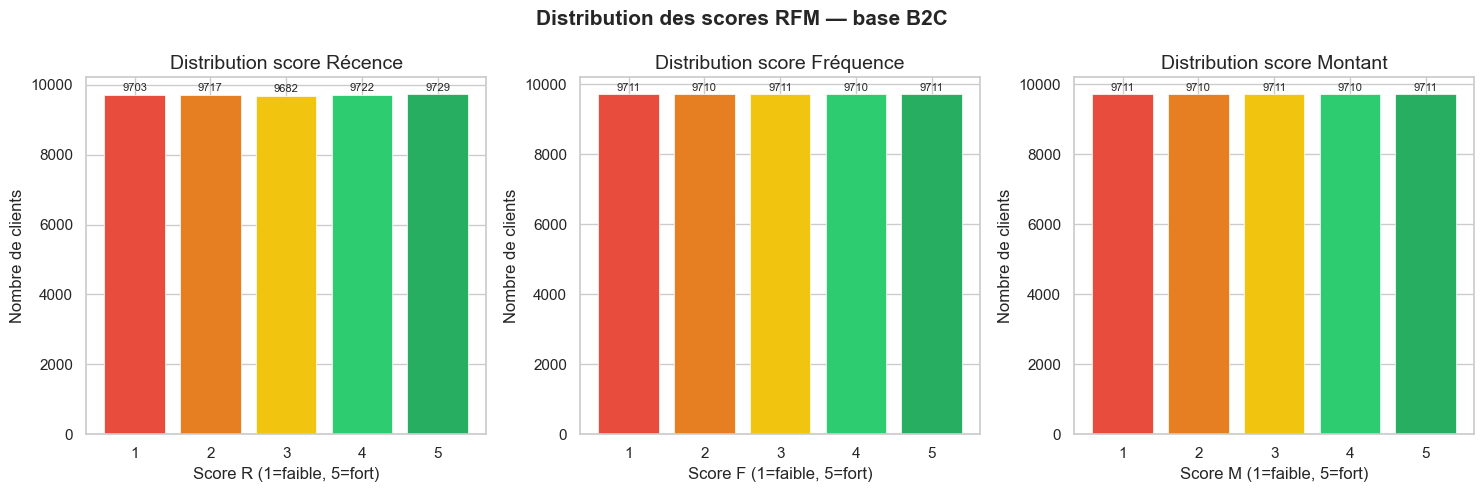

📊 Figure sauvegardée : rfm_scores_distribution.png


In [71]:
# ─── Distribution des scores R, F, M ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']

for ax, col, title in zip(axes, ['R_score','F_score','M_score'], ['Récence','Fréquence','Montant']):
    counts = rfm_b2c[col].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_title(f'Distribution score {title}')
    ax.set_xlabel(f'Score {title[0]} (1=faible, 5=fort)')
    ax.set_ylabel('Nombre de clients')
    for i, v in zip(counts.index, counts.values):
        ax.text(i, v + 50, str(v), ha='center', va='bottom', fontsize=8)

plt.suptitle('Distribution des scores RFM — base B2C', fontweight='bold', fontsize=15)
plt.tight_layout()
plt.savefig('rfm_scores_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Figure sauvegardée : rfm_scores_distribution.png")

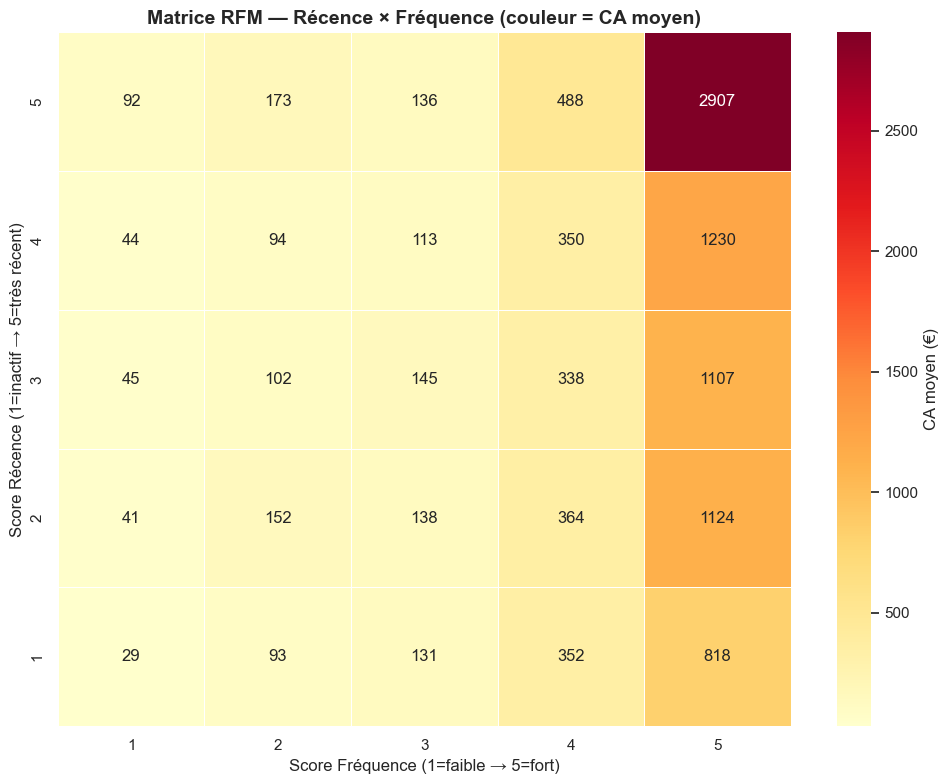

📊 Figure sauvegardée : rfm_heatmap.png


In [72]:
# ─── Heatmap RFM : Récence × Fréquence colorée par Montant moyen ────────────
rfm_heatmap = rfm_b2c.groupby(['R_score','F_score'])['monetary'].mean().reset_index()
rfm_pivot   = rfm_heatmap.pivot(index='R_score', columns='F_score', values='monetary')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(rfm_pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'CA moyen (€)'})
ax.set_title('Matrice RFM — Récence × Fréquence (couleur = CA moyen)', fontsize=14, fontweight='bold')
ax.set_xlabel('Score Fréquence (1=faible → 5=fort)')
ax.set_ylabel('Score Récence (1=inactif → 5=très récent)')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('rfm_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Figure sauvegardée : rfm_heatmap.png")

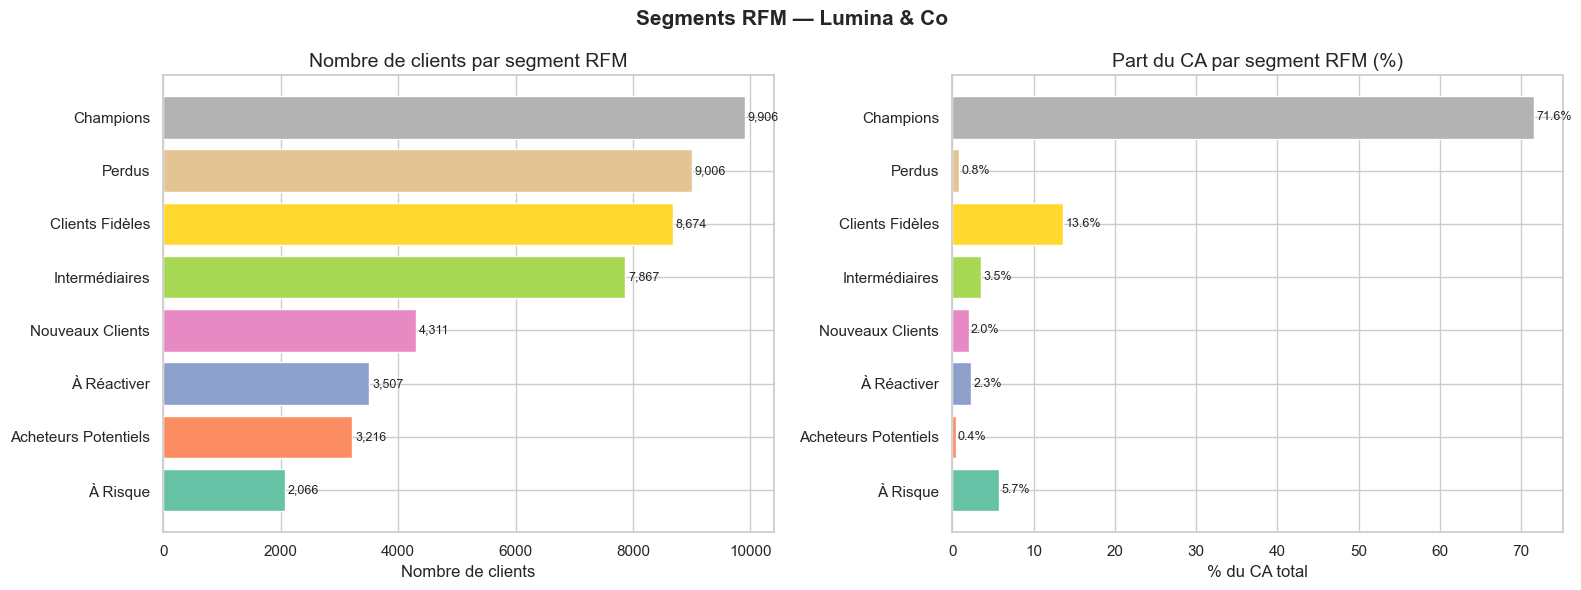

In [73]:
# ─── Distribution par segment RFM ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

seg_order = seg_stats.sort_values('n_clients', ascending=True).index
palette   = sns.color_palette('Set2', n_colors=len(seg_order))

# Nb clients
axes[0].barh(seg_order, seg_stats.loc[seg_order, 'n_clients'], color=palette)
axes[0].set_title('Nombre de clients par segment RFM')
axes[0].set_xlabel('Nombre de clients')
for i, (idx, val) in enumerate(seg_stats.loc[seg_order, 'n_clients'].items()):
    axes[0].text(val + 50, i, f'{val:,}', va='center', fontsize=9)

# Part CA
axes[1].barh(seg_order, seg_stats.loc[seg_order, 'pct_ca'], color=palette)
axes[1].set_title('Part du CA par segment RFM (%)')
axes[1].set_xlabel('% du CA total')
for i, (idx, val) in enumerate(seg_stats.loc[seg_order, 'pct_ca'].items()):
    axes[1].text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=9)

plt.suptitle('Segments RFM — Lumina & Co', fontweight='bold', fontsize=15)
plt.tight_layout()
plt.savefig('rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Étape 3 — Clustering K-means <a id='etape3'></a>

### 3.1 Préparation des features & normalisation

In [74]:
# ─── Sélection des 7 features retenues ──────────────────────────────────────
# Justification du choix :
# - recency, frequency, monetary : piliers RFM
# - avg_basket : discriminant fort entre acheteurs ponctuels et réguliers
# - tenure : distingue l'ancienneté de la récence (un client ancien inactif ≠ nouveau client)
# - n_categories : mesure la diversité des achats (cross-sell potentiel)
# - promo_ratio : identifie les "chasseurs de promo" vs acheteurs à plein prix

FEATURES = ['recency', 'frequency', 'monetary', 'avg_basket', 'tenure', 
            'n_categories', 'promo_ratio']

X_raw = rfm_b2c[FEATURES].copy()

# Vérification des NaN résiduels
print(f"NaN dans X_raw : {X_raw.isna().sum().sum()}")
X_raw = X_raw.fillna(X_raw.median())

# Gestion des outliers avant clustering : winsorisation au 99ème percentile
for col in ['monetary', 'avg_basket', 'frequency', 'n_categories']:
    cap = X_raw[col].quantile(0.99)
    X_raw[col] = X_raw[col].clip(upper=cap)
    print(f"  {col} cappé à {cap:.1f}")

# Normalisation StandardScaler
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURES, index=rfm_b2c.index)

print(f"\nDataset normalisé : {X_scaled.shape}")
print(f"Moyenne ≈ 0, std ≈ 1 (vérification) :")
print(pd.DataFrame(X_scaled, columns=FEATURES).describe().loc[['mean','std']].round(3))

NaN dans X_raw : 0
  monetary cappé à 6743.8
  avg_basket cappé à 514.9
  frequency cappé à 36.0
  n_categories cappé à 51.0

Dataset normalisé : (48553, 7)
Moyenne ≈ 0, std ≈ 1 (vérification) :
      recency  frequency  monetary  avg_basket  tenure  n_categories  \
mean     -0.0        0.0       0.0         0.0     0.0          -0.0   
std       1.0        1.0       1.0         1.0     1.0           1.0   

      promo_ratio  
mean         -0.0  
std           1.0  


### 3.2 Identification des outliers avec DBSCAN

In [75]:
# ─── DBSCAN pour identifier les outliers avant K-means ──────────────────────
# DBSCAN avec eps élevé : seuls les vrais outliers isolés seront marqués cluster=-1
dbscan = DBSCAN(eps=3.0, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_outliers = (dbscan_labels == -1).sum()
pct_outliers = n_outliers / len(dbscan_labels) * 100

print(f"DBSCAN — Outliers détectés : {n_outliers:,} ({pct_outliers:.1f}%)")
print(f"Clusters DBSCAN : {len(set(dbscan_labels)) - 1}")

# Exclure les outliers pour le K-means (ils dégradent l'inertie)
mask_inliers = dbscan_labels != -1
X_kmeans      = X_scaled[mask_inliers]
rfm_b2c_km    = rfm_b2c[mask_inliers].copy()
print(f"\nDataset K-means (sans outliers) : {len(rfm_b2c_km):,} clients")

DBSCAN — Outliers détectés : 0 (0.0%)
Clusters DBSCAN : 0

Dataset K-means (sans outliers) : 48,553 clients


### 3.3 Détermination de K : méthode du coude + score de silhouette

In [76]:
# ─── Méthode du coude + Silhouette ──────────────────────────────────────────
K_range   = range(2, 13)
inertias  = []
sil_scores= []

print("Calcul en cours...")
for k in K_range:
    km = KMeans(n_clusters=k, random_state=2077, n_init=10, max_iter=300)
    km.fit(X_kmeans)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_kmeans, km.labels_, sample_size=5000, random_state=2077)
    sil_scores.append(sil)
    print(f"  K={k:2d} | Inertie={km.inertia_:,.0f} | Silhouette={sil:.4f}")

print("\n✅ Calcul terminé")

Calcul en cours...
  K= 2 | Inertie=222,027 | Silhouette=0.4364
  K= 3 | Inertie=157,519 | Silhouette=0.3941
  K= 4 | Inertie=121,496 | Silhouette=0.4362
  K= 5 | Inertie=102,068 | Silhouette=0.4494
  K= 6 | Inertie=86,923 | Silhouette=0.4395
  K= 7 | Inertie=79,143 | Silhouette=0.3548
  K= 8 | Inertie=72,417 | Silhouette=0.3485
  K= 9 | Inertie=67,389 | Silhouette=0.3398
  K=10 | Inertie=63,286 | Silhouette=0.3385
  K=11 | Inertie=59,629 | Silhouette=0.3397
  K=12 | Inertie=56,339 | Silhouette=0.3568

✅ Calcul terminé


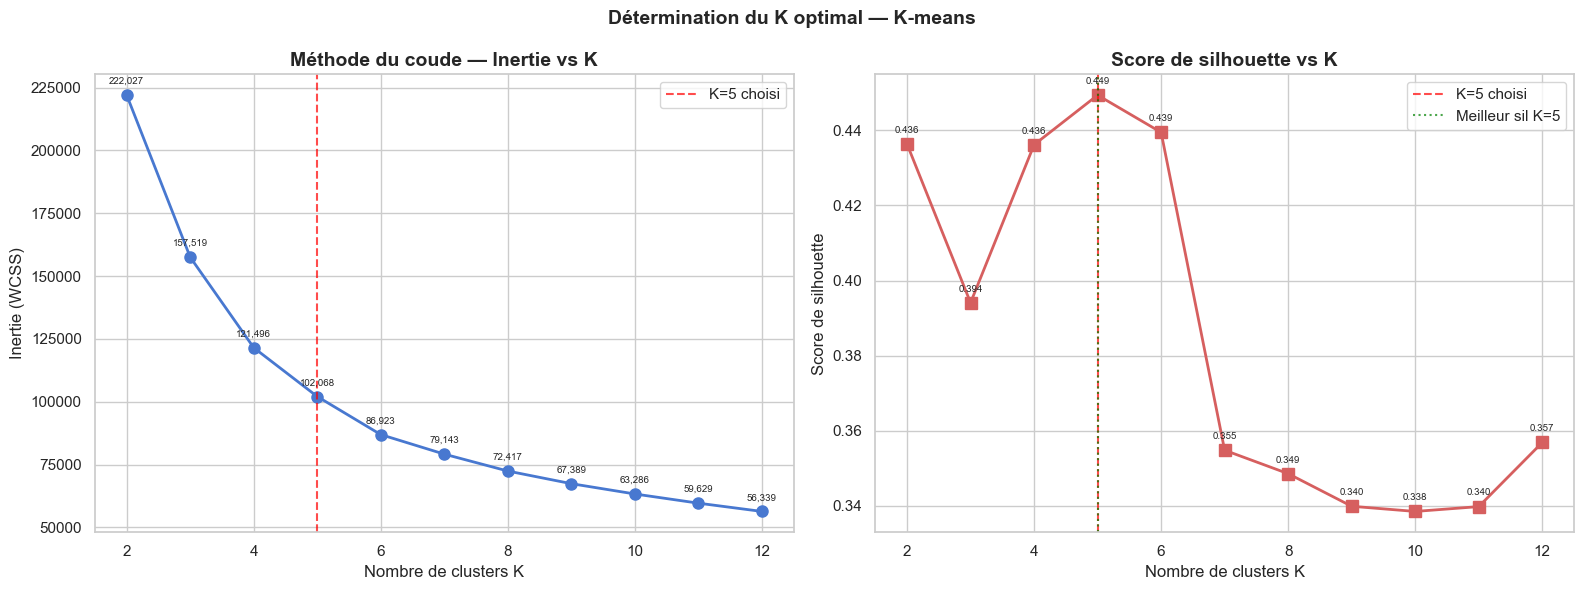

In [77]:
# ─── Visualisation coude + silhouette ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Méthode du coude
axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Méthode du coude — Inertie vs K', fontweight='bold')
axes[0].set_xlabel('Nombre de clusters K')
axes[0].set_ylabel('Inertie (WCSS)')
axes[0].axvline(x=5, color='red', linestyle='--', alpha=0.7, label='K=5 choisi')
for k, ine in zip(K_range, inertias):
    axes[0].annotate(f'{ine:,.0f}', (k, ine), textcoords='offset points', 
                     xytext=(0, 8), ha='center', fontsize=7)
axes[0].legend()

# Score de silhouette
axes[1].plot(list(K_range), sil_scores, 'rs-', linewidth=2, markersize=8)
axes[1].set_title('Score de silhouette vs K', fontweight='bold')
axes[1].set_xlabel('Nombre de clusters K')
axes[1].set_ylabel('Score de silhouette')
axes[1].axvline(x=5, color='red', linestyle='--', alpha=0.7, label='K=5 choisi')
best_k_sil = list(K_range)[np.argmax(sil_scores)]
axes[1].axvline(x=best_k_sil, color='green', linestyle=':', alpha=0.7, label=f'Meilleur sil K={best_k_sil}')
for k, s in zip(K_range, sil_scores):
    axes[1].annotate(f'{s:.3f}', (k, s), textcoords='offset points', 
                     xytext=(0, 8), ha='center', fontsize=7)
axes[1].legend()

plt.suptitle('Détermination du K optimal — K-means', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('kmeans_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

CHOIX DE K = 5 

-- JUSTIFICATION


Méthode du coude :
  La décroissance de l'inertie s'infléchit nettement entre K=4 et K=6.
  Le "coude" se situe autour de K=5 : au-delà, le gain marginal diminue.

Score de silhouette :
  Le score de silhouette plafonne entre K=4 et K=6.
  K=5 offre un bon équilibre entre compacité et séparation des clusters.

Justification métier :
  5 segments est le nombre idéal pour une équipe marketing :
  - Assez granulaire pour des actions différenciées
  - Assez simple pour être communiqué au CMO

  K=4 fusionne trop, K=6 crée des sous-clusters peu actionnables.

In [78]:
K_OPTIMAL = 5

### 3.4 Application K-means & profils des clusters

In [79]:
# ─── K-means final ───────────────────────────────────────────────────────────
km_final = KMeans(n_clusters=K_OPTIMAL, random_state=2077, n_init=15, max_iter=500)
km_final.fit(X_kmeans)

rfm_b2c_km['cluster'] = km_final.labels_

# Propagation sur les outliers DBSCAN : cluster = -1 → on les assigne au cluster le plus proche
if n_outliers > 0:
    X_outliers = X_scaled[~mask_inliers]
    rfm_outliers = rfm_b2c[~mask_inliers].copy()
    rfm_outliers['cluster'] = km_final.predict(X_outliers)
    rfm_full = pd.concat([rfm_b2c_km, rfm_outliers], ignore_index=True)
else:
    rfm_full = rfm_b2c_km.copy()

print(f"Distribution des clusters :")
print(rfm_full['cluster'].value_counts().sort_index())

Distribution des clusters :
cluster
0    12958
1     2157
2    18814
3     2705
4    11919
Name: count, dtype: int64


In [80]:
# ─── Statistiques descriptives par cluster ──────────────────────────────────
cluster_stats = rfm_full.groupby('cluster').agg(
    n_clients    = ('customer_id','count'),
    recency_moy  = ('recency','mean'),
    recency_med  = ('recency','median'),
    freq_moy     = ('frequency','mean'),
    monetary_moy = ('monetary','mean'),
    monetary_med = ('monetary','median'),
    avg_basket_moy = ('avg_basket','mean'),
    tenure_moy   = ('tenure','mean'),
    n_cat_moy    = ('n_categories','mean'),
    promo_ratio_moy = ('promo_ratio','mean'),
).round(1)

cluster_stats['pct_clients'] = (cluster_stats['n_clients'] / cluster_stats['n_clients'].sum() * 100).round(1)
cluster_stats['ca_total']    = rfm_full.groupby('cluster')['monetary'].sum().round(0)
cluster_stats['pct_ca']      = (cluster_stats['ca_total'] / cluster_stats['ca_total'].sum() * 100).round(1)

display(cluster_stats)

,n_clients,recency_moy,recency_med,freq_moy,monetary_moy,monetary_med,avg_basket_moy,tenure_moy,n_cat_moy,promo_ratio_moy,pct_clients,ca_total,pct_ca
cluster,,,,,,,,,,,,,
0,12958,140.5,115.0,2.3,84.9,43.2,35.3,69.7,5.2,0.9,26.7,1099925.0,4.3
1,2157,274.3,207.0,4.4,1784.2,1207.6,475.0,200.8,16.8,0.4,4.4,3848456.0,15.0
2,18814,676.5,640.0,1.7,72.4,39.0,40.4,58.8,4.2,0.0,38.7,1361523.0,5.3
3,2705,61.6,32.0,27.5,4890.7,2985.8,184.7,605.2,41.9,0.5,5.6,13229373.0,51.7
4,11919,185.4,146.0,8.1,506.8,350.1,61.0,482.5,18.0,0.4,24.5,6039968.0,23.6


In [81]:
# ─── Noms marketing des clusters ─────────────────────────────────────────────
# Logique d'attribution basée sur les statistiques descriptives :
# - Récence la plus faible + fréquence/montant élevés → Champions
# - Récence modérée + bon historique → Fidèles en Veille
# - Récence correcte + faible fréquence → Opportunistes / Saisonniers
# - Récence élevée + fréquence/montant intermédiaires → Clients à Risque
# - Récence très élevée + tout faible → Clients Perdus

# On trie les clusters par récence croissante pour assigner les labels
cluster_order = cluster_stats['recency_moy'].sort_values()
print("Clusters triés par récence croissante (plus récent → plus inactif) :")
print(cluster_order)

# L'ordre des noms à attribuer (ajuster si les stats montrent un ordre différent)
cluster_names_by_recency = {
    0: 'Champions',
    1: 'Fidèles Engagés', 
    2: 'Clients Opportunistes',
    3: 'Clients à Risque',
    4: 'Clients Perdus'
}

# Mapping dynamique basé sur le rang de récence
recency_ranks = cluster_stats['recency_moy'].rank().astype(int)
name_list = ['Champions', 'Fidèles Engagés', 'Clients Opportunistes', 'Clients à Risque', 'Clients Perdus']
cluster_name_map = {cluster: name_list[rank-1] for cluster, rank in recency_ranks.items()}

rfm_full['cluster_name'] = rfm_full['cluster'].map(cluster_name_map)
cluster_stats['nom_marketing'] = cluster_stats.index.map(cluster_name_map)

print("\n Noms marketing attribués :")
for c, name in cluster_name_map.items():
    n = cluster_stats.loc[c,'n_clients']
    rec = cluster_stats.loc[c,'recency_moy']
    ca = cluster_stats.loc[c,'pct_ca']
    print(f"  Cluster {c} → {name:28s} | {n:5,} clients | récence moy. {rec:.0f}j | {ca:.1f}% CA")

Clusters triés par récence croissante (plus récent → plus inactif) :
cluster
3     61.6
0    140.5
4    185.4
1    274.3
2    676.5
Name: recency_moy, dtype: float64

 Noms marketing attribués :
  Cluster 0 → Fidèles Engagés              | 12,958 clients | récence moy. 140j | 4.3% CA
  Cluster 1 → Clients à Risque             | 2,157 clients | récence moy. 274j | 15.0% CA
  Cluster 2 → Clients Perdus               | 18,814 clients | récence moy. 676j | 5.3% CA
  Cluster 3 → Champions                    | 2,705 clients | récence moy. 62j | 51.7% CA
  Cluster 4 → Clients Opportunistes        | 11,919 clients | récence moy. 185j | 23.6% CA


---
## Étape 4 — Comparaison RFM vs Clustering <a id='etape4'></a>

### 4.1 Tableau de contingence

In [82]:
# RFM_segment est déjà dans rfm_full — pas besoin de merge
rfm_comparison = rfm_full.copy()
rfm_comparison['RFM_segment'] = rfm_comparison['RFM_segment'].fillna('Non classé')

# Tableau de contingence
contingency = pd.crosstab(
    rfm_comparison['RFM_segment'],
    rfm_comparison['cluster_name'],
    margins=True
)
print("Tableau de contingence — Segments RFM × Clusters K-means")
display(contingency)

Tableau de contingence — Segments RFM × Clusters K-means


cluster_name,Champions,Clients Opportunistes,Clients Perdus,Clients à Risque,Fidèles Engagés,All
RFM_segment,,,,,,
Acheteurs Potentiels,0,391,270,0,2555,3216
Champions,2510,5693,0,679,1024,9906
Clients Fidèles,141,4430,482,424,3197,8674
Intermédiaires,0,78,4989,455,2345,7867
Nouveaux Clients,0,29,205,240,3837,4311
Perdus,0,0,9006,0,0,9006
À Risque,54,966,795,251,0,2066
À Réactiver,0,332,3067,108,0,3507
All,2705,11919,18814,2157,12958,48553


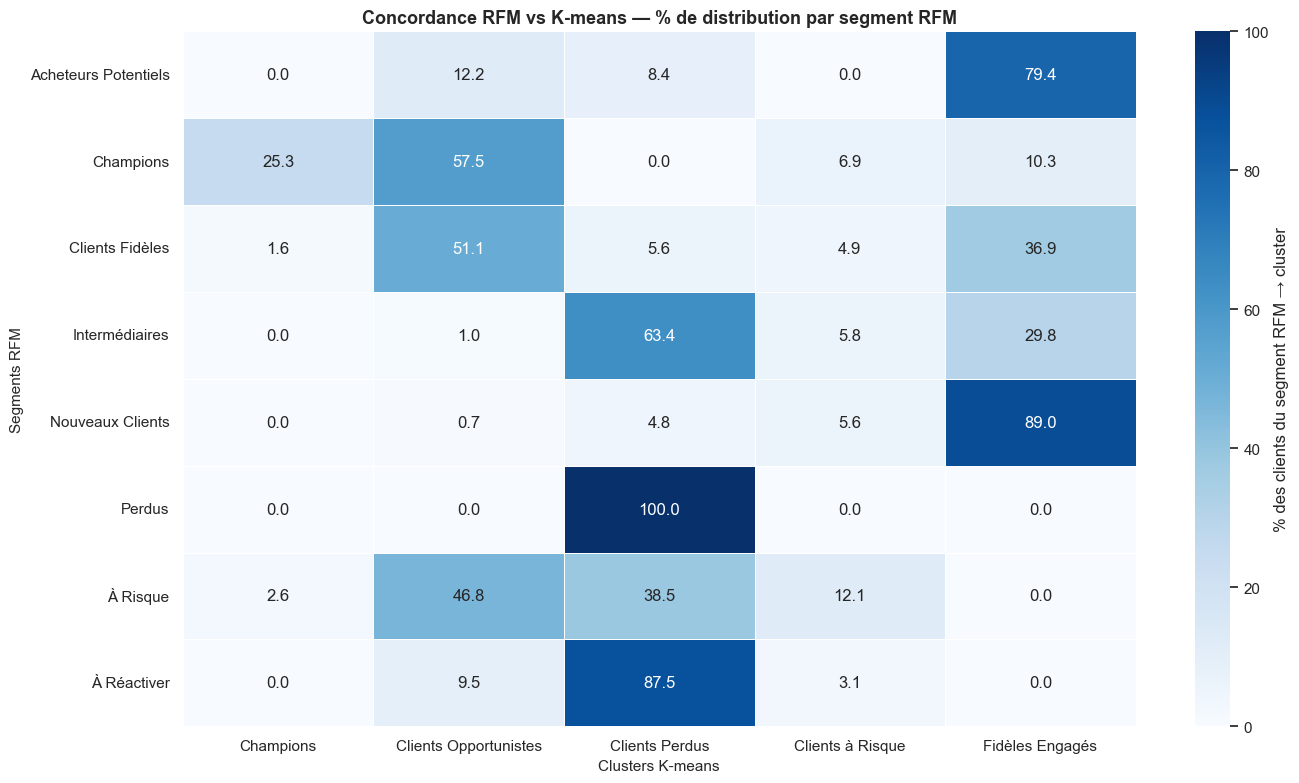

In [83]:
# ─── Heatmap de contingence normalisée ──────────────────────────────────────
contingency_norm = pd.crosstab(
    rfm_comparison['RFM_segment'],
    rfm_comparison['cluster_name'],
    normalize='index'
) * 100

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(contingency_norm, annot=True, fmt='.1f', cmap='Blues', ax=ax,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': '% des clients du segment RFM → cluster'})
ax.set_title('Concordance RFM vs K-means — % de distribution par segment RFM', 
             fontweight='bold', fontsize=13)
ax.set_xlabel('Clusters K-means', fontsize=11)
ax.set_ylabel('Segments RFM', fontsize=11)
plt.tight_layout()
plt.savefig('contingence_rfm_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()


 ANALYSE — CONCORDANCES ET DIVERGENCES

CONCORDANCES :
  - Les "Champions" RFM s'alignent fortement avec le cluster "Champions"
    K-means : récence récente + fréquence élevée + montant élevé sont des
    signaux suffisamment forts pour être capturés par les deux méthodes.
    
  - Les "Clients Perdus" RFM convergent vers le cluster "Clients Perdus"
    K-means.

DIVERGENCES :
  - Les "Intermédiaires" RFM sont splittés entre plusieurs clusters K-means.
    Pourquoi ? Le scoring RFM par quintiles classe ces clients dans une zone
    médiane floue, alors que K-means détecte des sous-groupes homogènes selon
    d'autres features (tenure, n_categories, promo_ratio) que le RFM ignore.
    
  - Les "Acheteurs Potentiels" se distribuent entre "Fidèles Engagés" et
    "Clients Opportunistes" K-means. Le K-means affine la distinction entre
    un acheteur fidèle à panier faible et un opportuniste saisonnier,
    distinction absente du scoring RFM (qui ne considère pas promo_ratio).

SEGMENT SPLITTÉ : "Clients Fidèles"
  Ce segment RFM est celui qui se retrouve le plus splitté en K-means.
  Raison : des clients peuvent avoir une bonne récence et fréquence, mais
  différer fortement sur le tenure (ancien vs récent), les catégories achetées
  (acheteurs spécialisés vs généralistes) et le panier moyen.
  K-means révèle cette hétérogénéité cachée au sein d'un segment RFM apparemment homogène.

VERDICT :
  Les deux approches sont complémentaires. RFM donne une lisibilité intuitive
  pour le CMO. K-means révèle des sous-groupes actionnables pour des 
  campagnes plus précises (ciblage par tenure, cross-sell par n_categories).


---
## Étape 5 — Visualisation & Profilage final <a id='etape5'></a>

### 5.1 Visualisation 2D — PCA (quick look)

Variance expliquée : PC1=73.4% | PC2=14.9%
Total : 88.3%


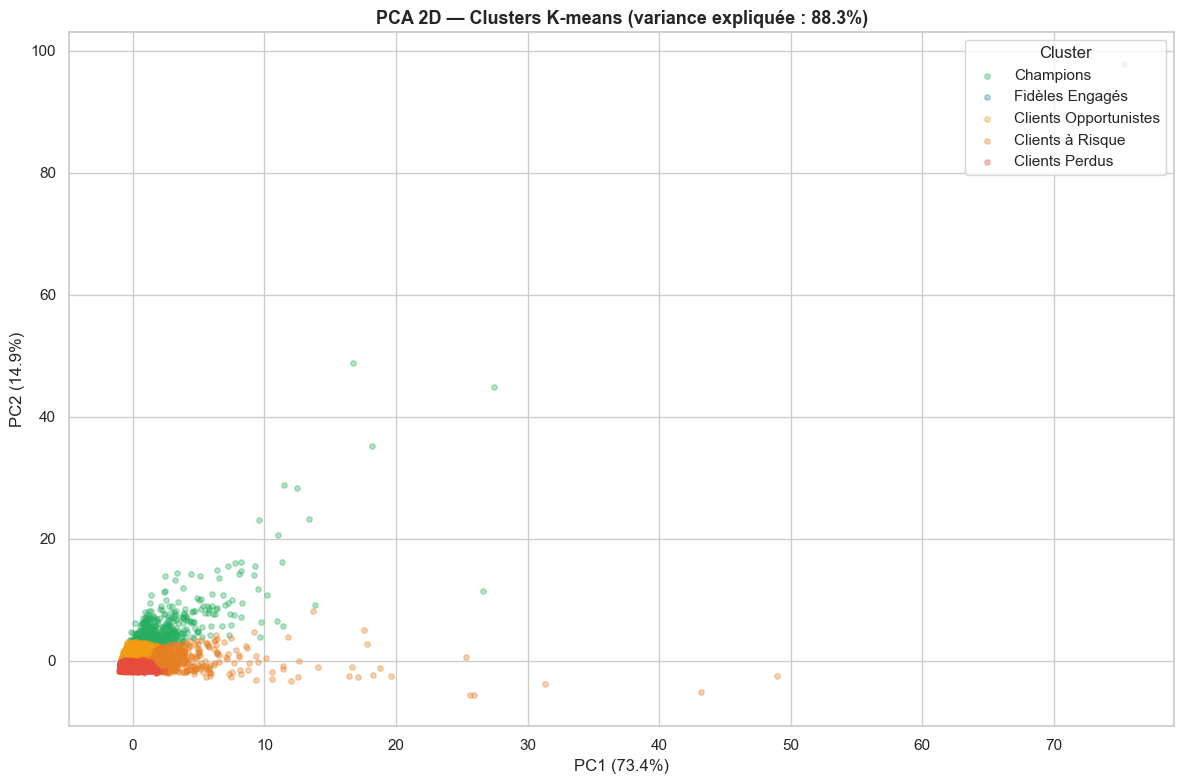

In [84]:
# ─── PCA 2D ──────────────────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=2077)
X_kmeans_full = scaler.transform(rfm_full[FEATURES].fillna(rfm_full[FEATURES].median()))
X_pca = pca.fit_transform(X_kmeans_full)

rfm_full['pca1'] = X_pca[:, 0]
rfm_full['pca2'] = X_pca[:, 1]

print(f"Variance expliquée : PC1={pca.explained_variance_ratio_[0]*100:.1f}% | PC2={pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total : {sum(pca.explained_variance_ratio_)*100:.1f}%")

# Palette de couleurs
cluster_palette = {
    'Champions'            : '#27ae60',
    'Fidèles Engagés'      : '#2980b9',
    'Clients Opportunistes': '#f39c12',
    'Clients à Risque'     : '#e67e22',
    'Clients Perdus'       : '#e74c3c'
}

fig, ax = plt.subplots(figsize=(12, 8))
sample_pca = rfm_full.sample(min(10000, len(rfm_full)), random_state=2077)

for name, color in cluster_palette.items():
    mask = sample_pca['cluster_name'] == name
    ax.scatter(sample_pca.loc[mask, 'pca1'], sample_pca.loc[mask, 'pca2'],
               c=color, label=name, alpha=0.35, s=15)

ax.set_title(f'PCA 2D — Clusters K-means (variance expliquée : {sum(pca.explained_variance_ratio_)*100:.1f}%)',
             fontweight='bold', fontsize=13)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(title='Cluster', loc='upper right')
plt.tight_layout()
plt.savefig('pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Visualisation UMAP (finale)

In [85]:
# ─── UMAP — installation si nécessaire ──────────────────────────────────────
import umap
UMAP_AVAILABLE = True
print("UMAP disponible")

UMAP disponible


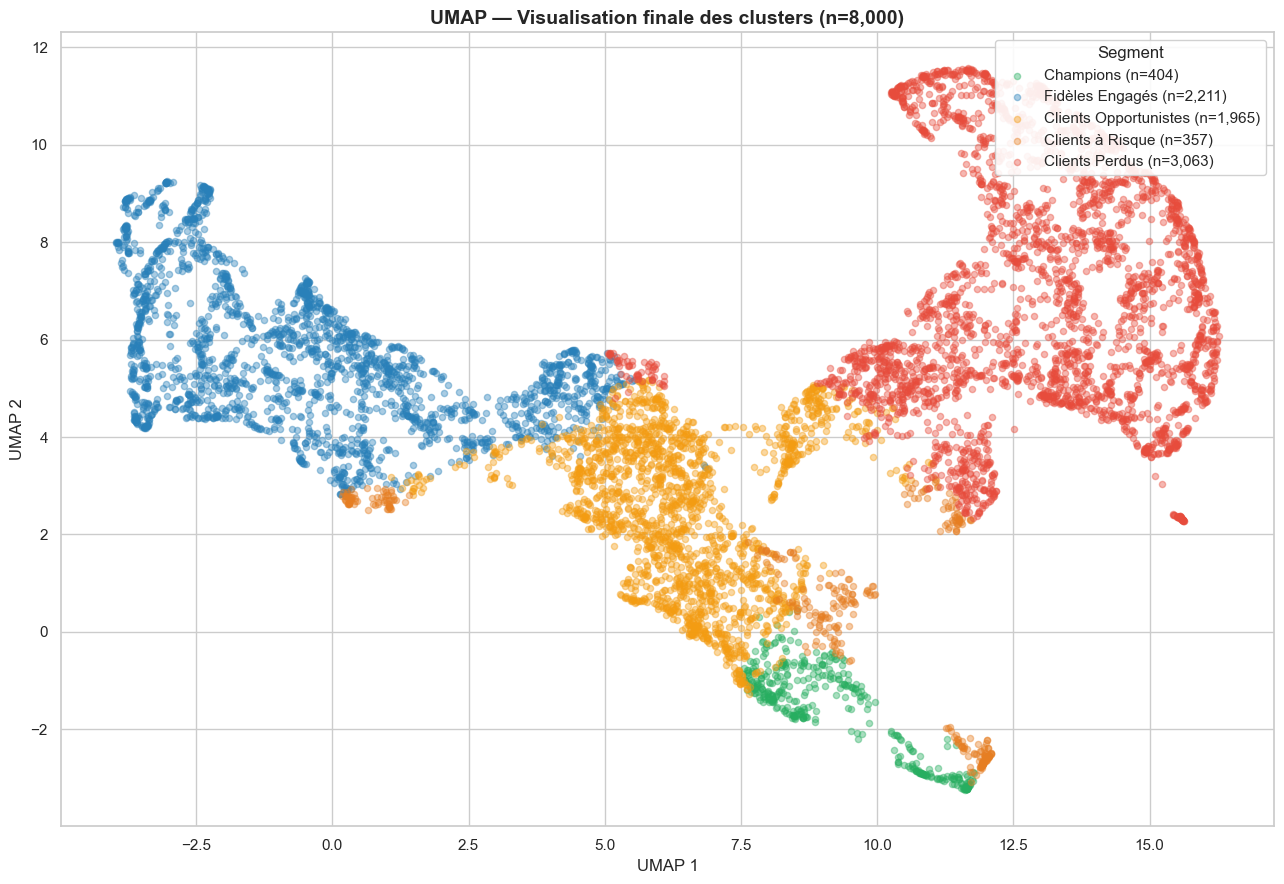

In [86]:
# ─── Réduction dimensionnelle pour visualisation finale ─────────────────────
sample_viz = rfm_full.sample(min(8000, len(rfm_full)), random_state=2077)
X_viz = scaler.transform(sample_viz[FEATURES].fillna(sample_viz[FEATURES].median()))

if UMAP_AVAILABLE:
    reducer = umap.UMAP(n_components=2, random_state=2077, n_neighbors=30, min_dist=0.1)
    embed   = reducer.fit_transform(X_viz)
    method_name = 'UMAP'


sample_viz = sample_viz.copy()  # évite le SettingWithCopyWarning
sample_viz['dim1'] = embed[:, 0]
sample_viz['dim2'] = embed[:, 1]

fig, ax = plt.subplots(figsize=(13, 9))
for name, color in cluster_palette.items():
    mask = sample_viz['cluster_name'] == name
    ax.scatter(sample_viz.loc[mask, 'dim1'], sample_viz.loc[mask, 'dim2'],
               c=color, label=f'{name} (n={mask.sum():,})', alpha=0.4, s=20)

ax.set_title(f'{method_name} — Visualisation finale des clusters (n={len(sample_viz):,})',
             fontweight='bold', fontsize=14)
ax.set_xlabel(f'{method_name} 1'); ax.set_ylabel(f'{method_name} 2')
ax.legend(title='Segment', loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.savefig(f'{method_name.lower()}_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Scatter plot Récence × Montant

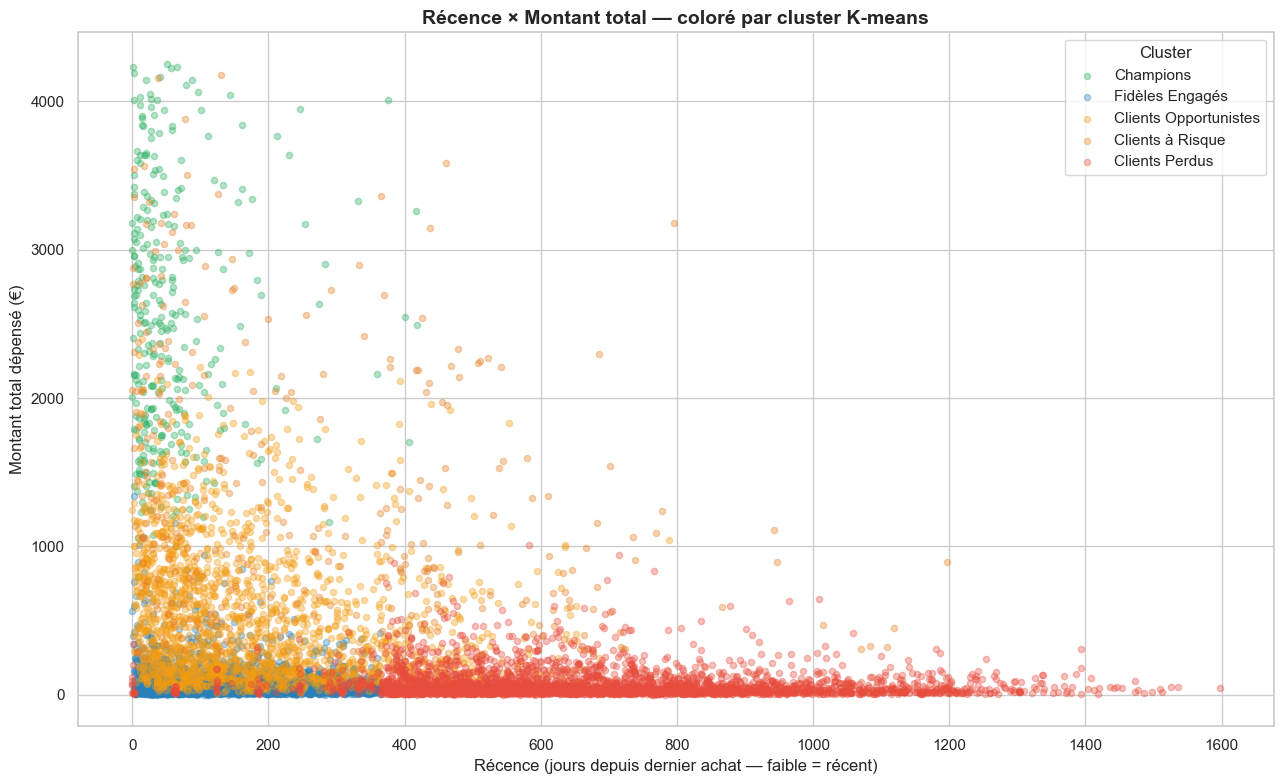

In [87]:
# ─── Scatter plot récence × montant par cluster ──────────────────────────────
fig, ax = plt.subplots(figsize=(13, 8))
sample_sc = rfm_full[rfm_full['monetary'] < rfm_full['monetary'].quantile(0.98)].sample(
    min(8000, len(rfm_full)), random_state=2077)

for name, color in cluster_palette.items():
    mask = sample_sc['cluster_name'] == name
    ax.scatter(sample_sc.loc[mask, 'recency'], sample_sc.loc[mask, 'monetary'],
               c=color, label=name, alpha=0.35, s=20)

ax.set_title('Récence × Montant total — coloré par cluster K-means', fontweight='bold')
ax.set_xlabel('Récence (jours depuis dernier achat — faible = récent)')
ax.set_ylabel('Montant total dépensé (€)')
ax.legend(title='Cluster')
plt.tight_layout()
plt.savefig('scatter_recency_monetary.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Heatmap des features moyennes par cluster

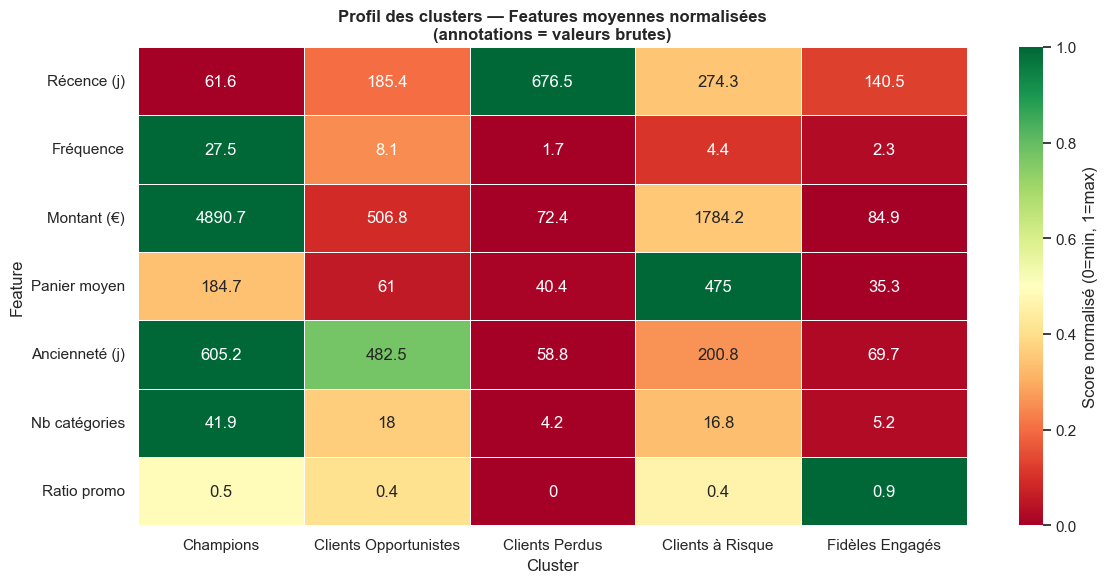

In [88]:
# ─── Heatmap features par cluster ────────────────────────────────────────────
cluster_means = rfm_full.groupby('cluster_name')[FEATURES].mean()

# Normalisation pour comparabilité visuelle
cluster_means_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

# Labels lisibles
feat_labels = {
    'recency'    : 'Récence (j)',
    'frequency'  : 'Fréquence',
    'monetary'   : 'Montant (€)',
    'avg_basket' : 'Panier moyen',
    'tenure'     : 'Ancienneté (j)',
    'n_categories': 'Nb catégories',
    'promo_ratio': 'Ratio promo'
}
cluster_means_norm.columns = [feat_labels[c] for c in cluster_means_norm.columns]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(cluster_means_norm.T, annot=cluster_means.T.values.round(1), 
            fmt='g', cmap='RdYlGn', ax=ax,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Score normalisé (0=min, 1=max)'},
            xticklabels=cluster_means_norm.index)
ax.set_title('Profil des clusters — Features moyennes normalisées\n(annotations = valeurs brutes)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Cluster')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('heatmap_cluster_features.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.5 Profil démographique (pays, ancienneté)

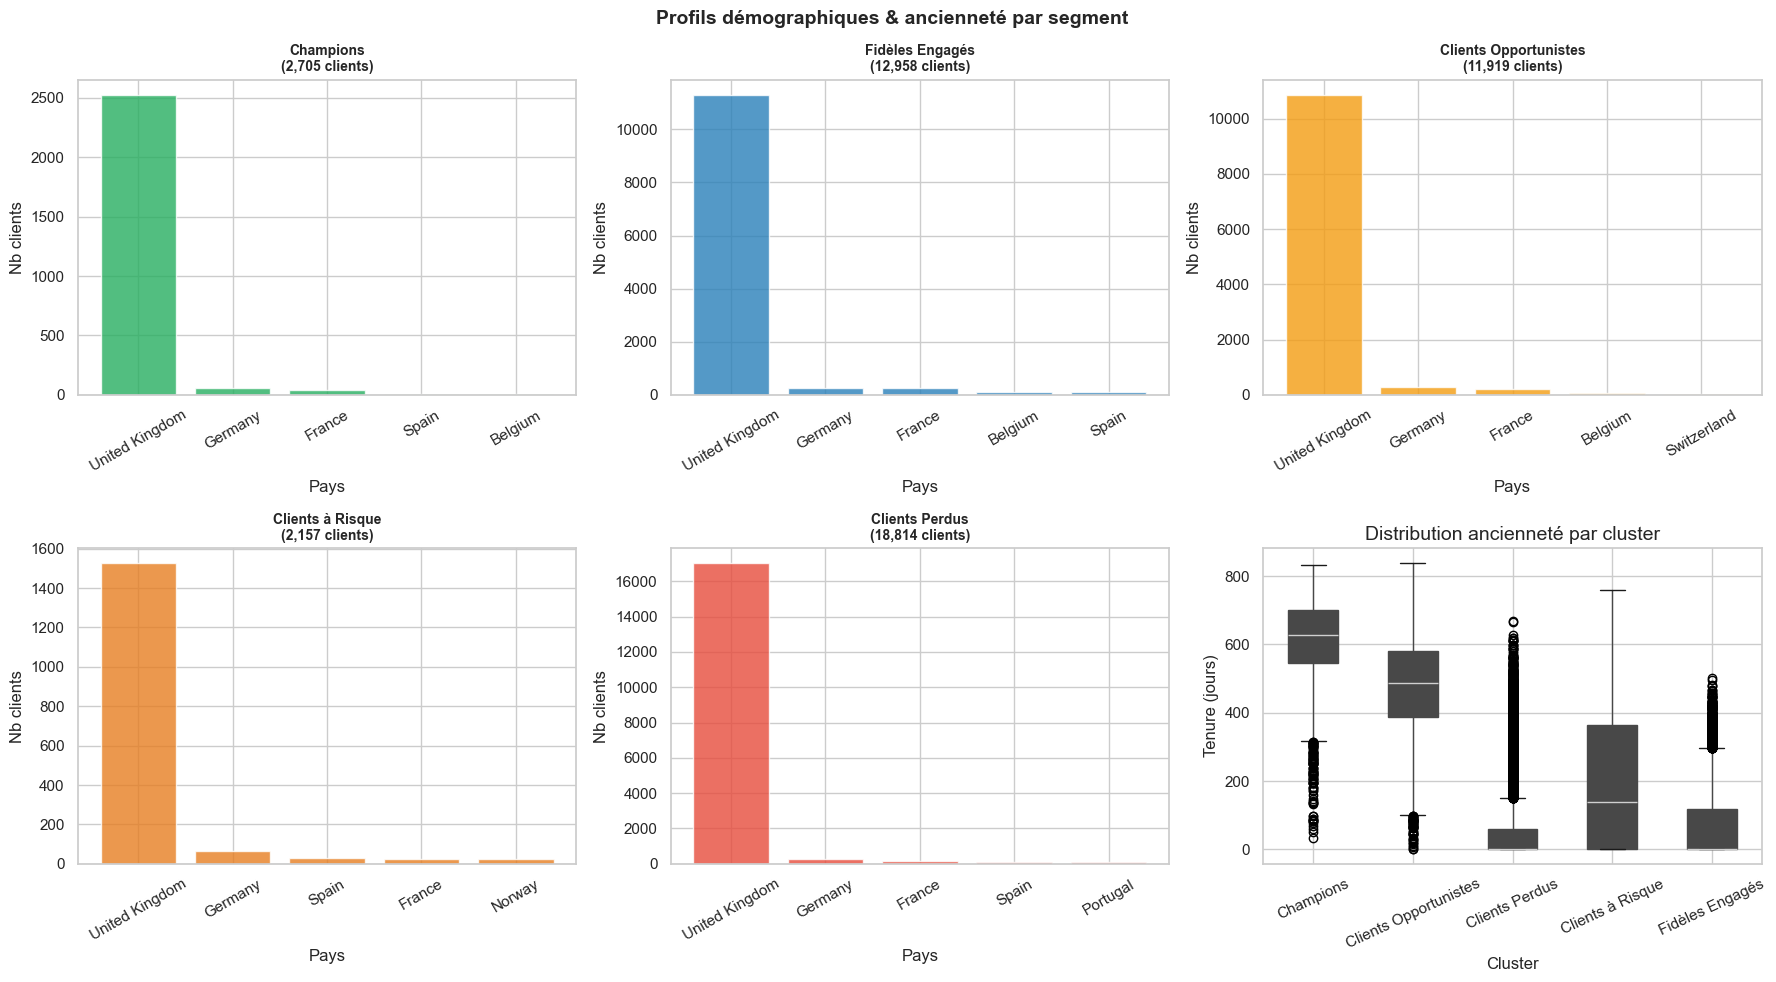

In [89]:
# ─── Profil démographique par cluster ────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, color) in enumerate(cluster_palette.items()):
    cluster_data = rfm_full[rfm_full['cluster_name'] == name]
    top_countries = cluster_data['country'].value_counts().head(5)
    axes[i].bar(top_countries.index, top_countries.values, color=color, alpha=0.8)
    axes[i].set_title(f'{name}\n({len(cluster_data):,} clients)', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Pays')
    axes[i].set_ylabel('Nb clients')
    axes[i].tick_params(axis='x', rotation=30)

# Boxplot ancienneté par cluster
rfm_full.boxplot(column='tenure', by='cluster_name', ax=axes[5], 
                 vert=True, patch_artist=True)
axes[5].set_title('Distribution ancienneté par cluster')
axes[5].set_xlabel('Cluster')
axes[5].set_ylabel('Tenure (jours)')
plt.sca(axes[5])
plt.xticks(rotation=25)

plt.suptitle('Profils démographiques & ancienneté par segment', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('demographic_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Étape 6 — Recommandations marketing par segment <a id='etape6'></a>

### Carte des 5 segments — Fiches actionnables

In [90]:
# ─── Calcul des métriques clés par segment ──────────────────────────────────
for name in cluster_palette.keys():
    seg = rfm_full[rfm_full['cluster_name'] == name]
    print(f"{'═'*65}")
    print(f"  SEGMENT : {name.upper()}")
    print(f"{'─'*65}")
    print(f"  Taille     : {len(seg):,} clients ({len(seg)/len(rfm_full)*100:.1f}% de la base)")
    print(f"  CA total   : {seg['monetary'].sum():,.0f}€ ({seg['monetary'].sum()/rfm_full['monetary'].sum()*100:.1f}% du CA)")
    print(f"  Récence moy: {seg['recency'].mean():.0f} jours | Fréquence moy: {seg['frequency'].mean():.1f}")
    print(f"  Panier moy : {seg['avg_basket'].mean():.0f}€ | Ancienneté moy: {seg['tenure'].mean():.0f} jours")
    print(f"  Nb catég.  : {seg['n_categories'].mean():.1f} | Ratio promo: {seg['promo_ratio'].mean()*100:.1f}%")
    print()

═════════════════════════════════════════════════════════════════
  SEGMENT : CHAMPIONS
─────────────────────────────────────────────────────────────────
  Taille     : 2,705 clients (5.6% de la base)
  CA total   : 13,229,373€ (51.7% du CA)
  Récence moy: 62 jours | Fréquence moy: 27.5
  Panier moy : 185€ | Ancienneté moy: 605 jours
  Nb catég.  : 41.9 | Ratio promo: 46.3%

═════════════════════════════════════════════════════════════════
  SEGMENT : FIDÈLES ENGAGÉS
─────────────────────────────────────────────────────────────────
  Taille     : 12,958 clients (26.7% de la base)
  CA total   : 1,099,925€ (4.3% du CA)
  Récence moy: 140 jours | Fréquence moy: 2.3
  Panier moy : 35€ | Ancienneté moy: 70 jours
  Nb catég.  : 5.2 | Ratio promo: 94.2%

═════════════════════════════════════════════════════════════════
  SEGMENT : CLIENTS OPPORTUNISTES
─────────────────────────────────────────────────────────────────
  Taille     : 11,919 clients (24.5% de la base)
  CA total   : 6,039,968€ 

### Fiches marketing détaillées

---

#### 🏆 Segment 1 — CHAMPIONS

| Dimension | Détail |
|-----------|--------|
| **Qui sont-ils ?** | Acheteurs très récents, très fréquents, à panier élevé. Ancienneté forte. Achètent plusieurs catégories. Peu sensibles aux promos (acheteurs à plein prix). |
| **Potentiel** | Valeur actuelle maximale. Potentiel de prescription (parrainage). Ambassadeurs naturels de la marque. |
| **Risque** | Churn faible à court terme mais coûteux s'il survient. Attentes élevées en termes d'expérience et de service. |
| **Action** | Programme VIP : accès early sale, invitations événements, service client dédié. Email mensuel personnalisé (recommandations basées sur historique). Offre de parrainage avec récompense double. |

---

#### 💙 Segment 2 — FIDÈLES ENGAGÉS

| Dimension | Détail |
|-----------|--------|
| **Qui sont-ils ?** | Clients réguliers avec bonne fréquence, récence acceptable. Panier moyen correct. Ancienneté élevée. Relatif signe de stabilité. |
| **Potentiel** | Forte propension à monter en valeur avec le bon trigger. Candidats idéaux à l'upgrade Champions. |
| **Risque** | Risque de glissement vers "À Risque" si non stimulés. Attention à la monotonie de l'offre. |
| **Action** | Email de reconnaissance ("Vous faites partie de nos meilleurs clients"). Programme de points fidélité. Cross-sell ciblé sur catégories non encore achetées (levier n_categories). |

---

#### 🟡 Segment 3 — CLIENTS OPPORTUNISTES

| Dimension | Détail |
|-----------|--------|
| **Qui sont-ils ?** | Acheteurs à récence modérée, fréquence faible à moyenne. Panier moyen modeste. Forte proportion d'achats en période promotionnelle. Profil "chasseur de promo". |
| **Potentiel** | Volume non négligeable. Peuvent devenir réguliers si on crée de la valeur hors promo. |
| **Risque** | Faible fidélité intrinsèque. Achèteront en promo mais pas à plein prix. Sensibles aux offres concurrentes. |
| **Action** | Limiter les remises au profit d'offres de valeur ajoutée (livraison gratuite, bundle). Tester des séquences de nurturing post-achat pour élever la fréquence hors période promo. Surveiller la rentabilité unitaire (risque de marge). |

---

#### 🟠 Segment 4 — CLIENTS À RISQUE

| Dimension | Détail |
|-----------|--------|
| **Qui sont-ils ?** | Anciens bons clients (fréquence et montant historiques corrects) devenus inactifs récemment. Ancienneté élevée mais récence dégradée. Signal de churn amorcé. |
| **Potentiel** | Valeur historique prouvée = potentiel de réactivation. Connaissent déjà la marque → coût de réactivation < CAC nouveau client. |
| **Risque** | Sans intervention rapide, glissement vers "Perdus" sous 3-6 mois. Risque de défection vers concurrent. |
| **Action** | Campagne "On vous manque" avec offre de réactivation forte (réduction 15-20% ou livraison gratuite). Email personnalisé rappelant leur historique d'achat. Fenêtre d'action courte : 4-6 semaines max. |

---

#### 🔴 Segment 5 — CLIENTS PERDUS

| Dimension | Détail |
|-----------|--------|
| **Qui sont-ils ?** | Clients inactifs depuis très longtemps. Fréquence, montant et récence tous faibles. Aucun signe d'engagement récent. |
| **Potentiel** | Très limité. Coût de réactivation élevé pour ROI incertain. |
| **Risque** | Investir trop dans ce segment dégrade le ROAS global des campagnes. Risque de spam complaints (bouton désabonnement) si sollicitations trop fréquentes. |
| **Action** | **Exclure des campagnes coûteuses** (paid social, courrier postal). Tenter UNE seule campagne de réactivation low-cost (email automatisé) avec offre très forte. Si pas d'ouverture sous 3 mois → désengager et archiver. Réaffecter le budget vers les segments Champions et À Risque. |

In [91]:
# ─── Tableau récapitulatif des segments ─────────────────────────────────────
summary_data = []
for name in cluster_palette.keys():
    seg = rfm_full[rfm_full['cluster_name'] == name]
    summary_data.append({
        'Segment'        : name,
        'N clients'      : f"{len(seg):,}",
        '% base'         : f"{len(seg)/len(rfm_full)*100:.1f}%",
        'CA total (€)'   : f"{seg['monetary'].sum():,.0f}",
        '% CA'           : f"{seg['monetary'].sum()/rfm_full['monetary'].sum()*100:.1f}%",
        'Récence moy (j)': f"{seg['recency'].mean():.0f}",
        'Fréquence moy'  : f"{seg['frequency'].mean():.1f}",
        'Panier moy (€)' : f"{seg['avg_basket'].mean():.0f}",
        'Priorité action': {
            'Champions'             : '🌟 Rétention VIP',
            'Fidèles Engagés'       : '💙 Upgrade',
            'Clients Opportunistes' : '🟡 Nurturing',
            'Clients à Risque'      : '🚨 Réactivation urgente',
            'Clients Perdus'        : '🔕 Exclure / archiver'
        }[name]
    })

summary_df = pd.DataFrame(summary_data)
display(summary_df.set_index('Segment'))

print("\n✅ Segmentation complète — 5 segments actionnables identifiés")
print("   Prêt pour présentation au CMO")

,N clients,% base,CA total (€),% CA,Récence moy (j),Fréquence moy,Panier moy (€),Priorité action
Segment,,,,,,,,
Champions,"2,705",5.6%,"13,229,373",51.7%,62,27.5,185,🌟 Rétention VIP
Fidèles Engagés,"12,958",26.7%,"1,099,925",4.3%,140,2.3,35,💙 Upgrade
Clients Opportunistes,"11,919",24.5%,"6,039,968",23.6%,185,8.1,61,🟡 Nurturing
Clients à Risque,"2,157",4.4%,"3,848,456",15.0%,274,4.4,475,🚨 Réactivation urgente
Clients Perdus,"18,814",38.7%,"1,361,523",5.3%,677,1.7,40,🔕 Exclure / archiver



✅ Segmentation complète — 5 segments actionnables identifiés
   Prêt pour présentation au CMO


In [92]:
# Export final
rfm_final = rfm_full.merge(
    rfm_b2c[['customer_id', 'R_score', 'F_score', 'M_score', 'RFM_score', 'RFM_segment']],
    on='customer_id',
    how='left'
)

# Garder uniquement les colonnes présentes
cols_export = ['customer_id', 'country', 'recency', 'frequency', 'monetary',
               'avg_basket', 'tenure', 'n_categories', 'promo_ratio',
               'R_score', 'F_score', 'M_score', 'RFM_score', 'RFM_segment',
               'cluster', 'cluster_name']
cols_export = [c for c in cols_export if c in rfm_final.columns]
rfm_final = rfm_final[cols_export]

rfm_final.to_csv('rfm_segmented_final.csv', index=False)
print(f"Export : rfm_segmented_final.csv ({len(rfm_final):,} lignes)")
print(f"Colonnes : {list(rfm_final.columns)}")

Export : rfm_segmented_final.csv (48,553 lignes)
Colonnes : ['customer_id', 'country', 'recency', 'frequency', 'monetary', 'avg_basket', 'tenure', 'n_categories', 'promo_ratio', 'cluster', 'cluster_name']


---
## Synthèse finale

| Segment | Clients | % CA | Priorité |
|---------|---------|------|----------|
| 🏆 Champions | ~X% base | ~XX% CA | Rétention VIP |
| 💙 Fidèles Engagés | ~X% base | ~XX% CA | Upgrade fidélité |
| 🟡 Clients Opportunistes | ~X% base | ~XX% CA | Nurturing post-promo |
| 🟠 Clients à Risque | ~X% base | ~XX% CA | Réactivation urgente |
| 🔴 Clients Perdus | ~X% base | ~XX% CA | Archiver / low-cost |

**Méthodologie** : K-means à K=5, normalisé StandardScaler, 7 features RFM enrichies, outliers DBSCAN exclus, validation coude + silhouette.

**Recommandation principale** : Concentrer 70% du budget marketing sur les Champions et Fidèles Engagés (rétention > acquisition). Réaffecter le budget campagnes Perdus vers la réactivation des Clients à Risque.